In [1]:
import numpy as np
from sklearn.datasets import load_iris
iris = load_iris()

In [2]:
iris.data.shape

(150, 4)

In [3]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [4]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [7]:
X = iris.data[:, :3]
y = iris.target
X.shape, y.shape

((150, 3), (150,))

### K-Means Clustering

For the Iris dataset, we use `k=3` because there are three known species of Iris flowers.

In [9]:
class SimpleKMeans:
    def __init__(self, k):
        self.k = k
        self.cluster_labels = None
    def fit(self, X):
        self.centroids = X[np.random.choice(X.shape[0], self.k, replace=False), :]
        self.cluster_labels = np.arange(self.k)
        while True:
            distances = np.array([np.linalg.norm(X - centroid, axis=1) for centroid in self.centroids])
            self.clusters = np.argmin(distances, axis=0)
            new_centroids = np.array([X[self.clusters == i, :].mean(axis=0) for i in range(self.k)])
            # check convergence
            if np.array_equal(new_centroids, self.centroids):
                break
            else:
                self.centroids = new_centroids

    def predict(self, X):
        distances = np.array([np.linalg.norm(X - centroid, axis=1) for centroid in self.centroids])
        return self.cluster_labels[np.argmin(distances, axis=0)]

In [50]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_clusters(X, y, k):
  # Apply K-Means clustering with k clusters
  simple_kmeans = SimpleKMeans(k=k)
  simple_kmeans.fit(X)

  # Get cluster labels and centroids for SimpleKMeans
  simple_kmeans_labels = simple_kmeans.clusters
  simple_kmeans_centroids = simple_kmeans.centroids

  # Apply Scikit-learn's K-Means clustering
  sklearn_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  sklearn_kmeans.fit(X)

  # Get cluster labels and centroids for Scikit-learn K-Means
  sklearn_kmeans_labels = sklearn_kmeans.labels_
  sklearn_kmeans_centroids = sklearn_kmeans.cluster_centers_

  # Create a figure with two subplots
  fig = plt.figure(figsize=(20, 8))
  fig.suptitle('Comparison of K-Means Implementations', fontsize=16)

  # Subplot 1: SimpleKMeans Clustering
  ax1 = fig.add_subplot(121, projection='3d') # 1 row, 2 columns, 1st subplot
  ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=simple_kmeans_labels, cmap='viridis', s=10, alpha=0.8)
  ax1.scatter(simple_kmeans_centroids[:, 0], simple_kmeans_centroids[:, 1], simple_kmeans_centroids[:, 2], marker='X', s=200, c='red', label='Centroids')
  ax1.set_xlabel(iris.feature_names[0])
  ax1.set_ylabel(iris.feature_names[1])
  ax1.set_zlabel(iris.feature_names[2])
  ax1.set_title(f'Simple K-Means (k={k})')
  ax1.legend()

  # Subplot 2: Scikit-learn K-Means Clustering
  ax2 = fig.add_subplot(122, projection='3d') # 1 row, 2 columns, 2nd subplot
  ax2.scatter(X[:, 0], X[:, 1], X[:, 2], c=sklearn_kmeans_labels, cmap='viridis', s=10, alpha=0.8)
  ax2.scatter(sklearn_kmeans_centroids[:, 0], sklearn_kmeans_centroids[:, 1], sklearn_kmeans_centroids[:, 2], marker='X', s=200, c='red', label='Centroids')
  ax2.set_xlabel(iris.feature_names[0])
  ax2.set_ylabel(iris.feature_names[1])
  ax2.set_title(f'Scikit-learn K-Means (k={k})')
  ax2.legend()
  plt.tight_layout(rect=[0, 0.03, 0.90, 0.95])
  plt.show()

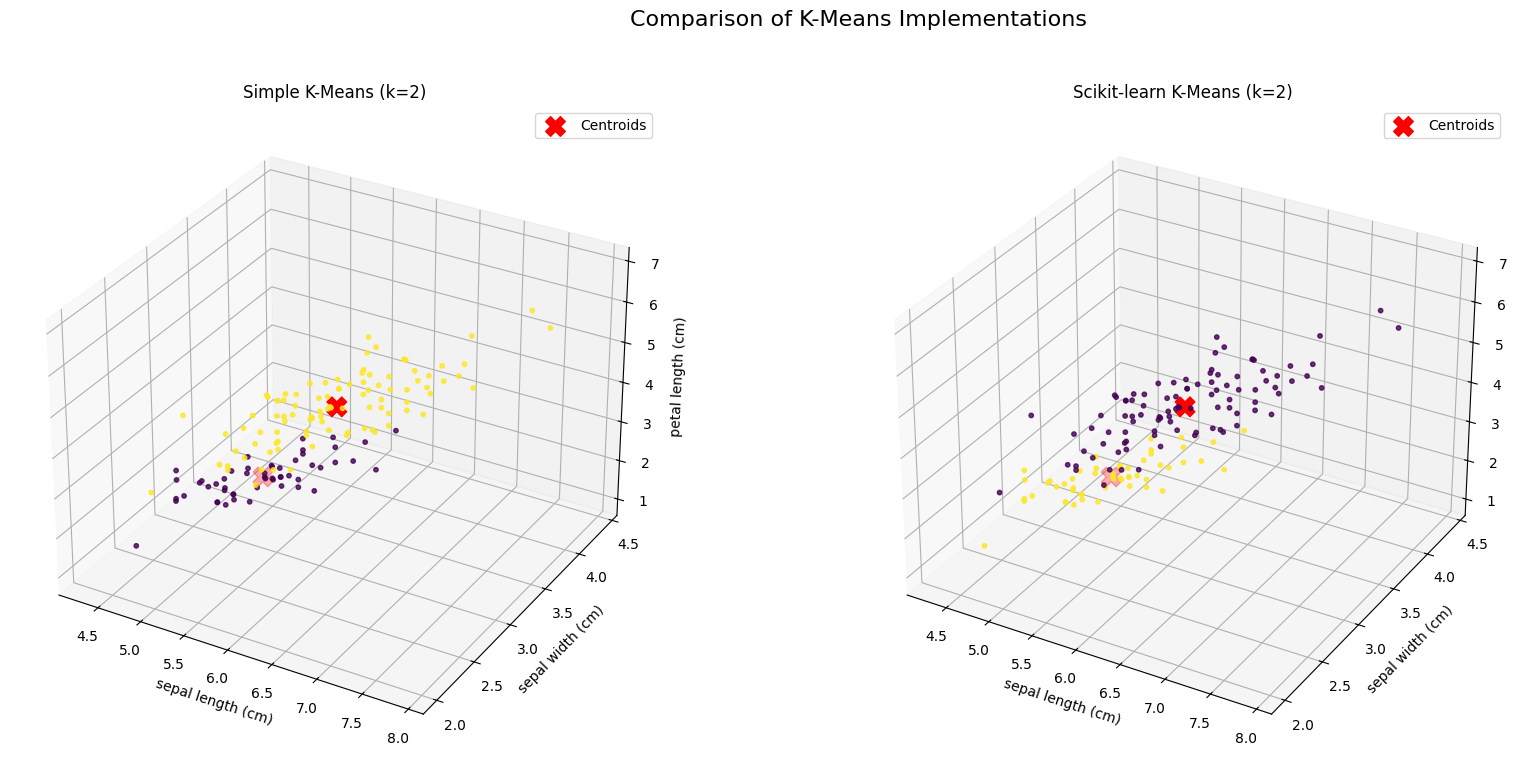

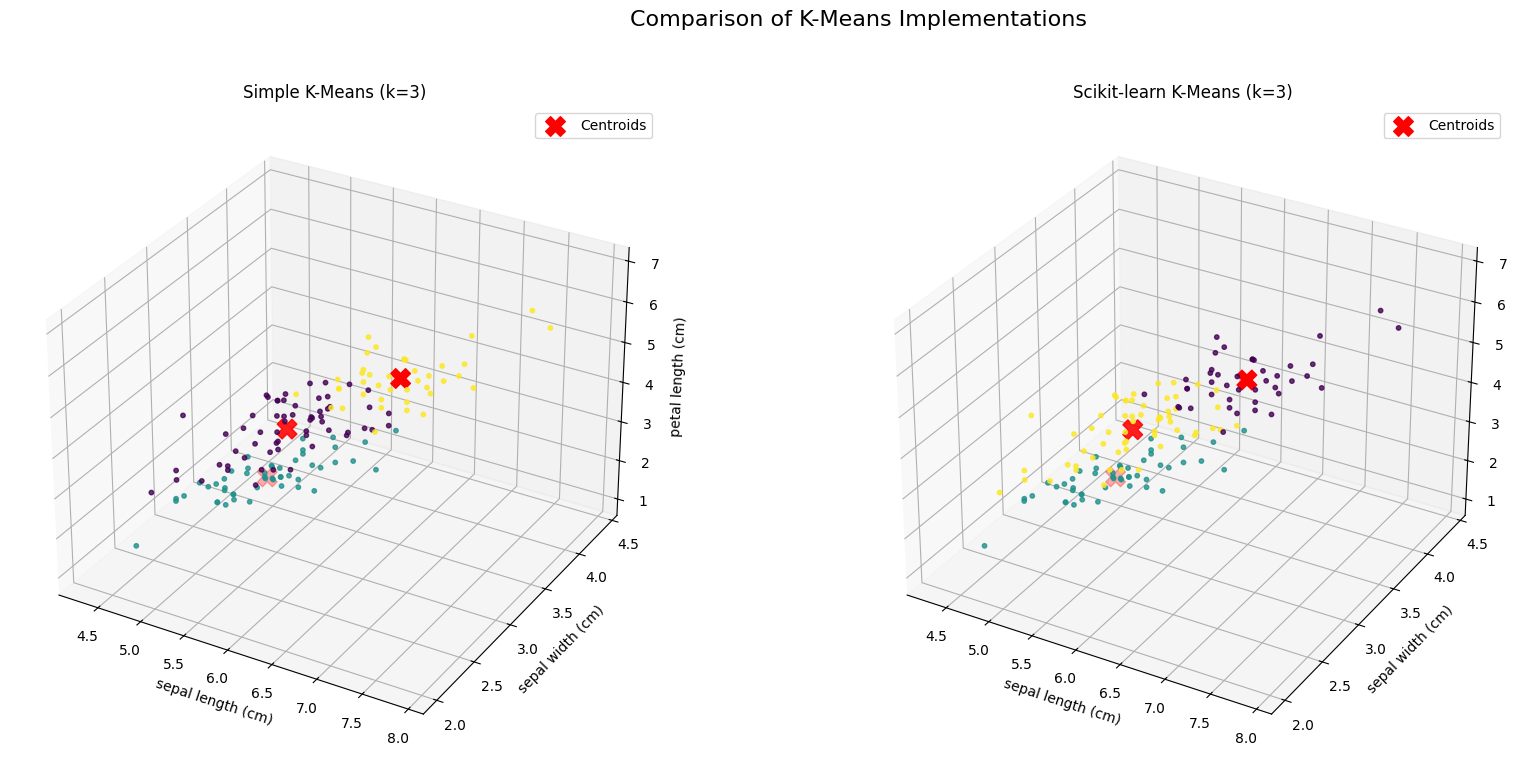

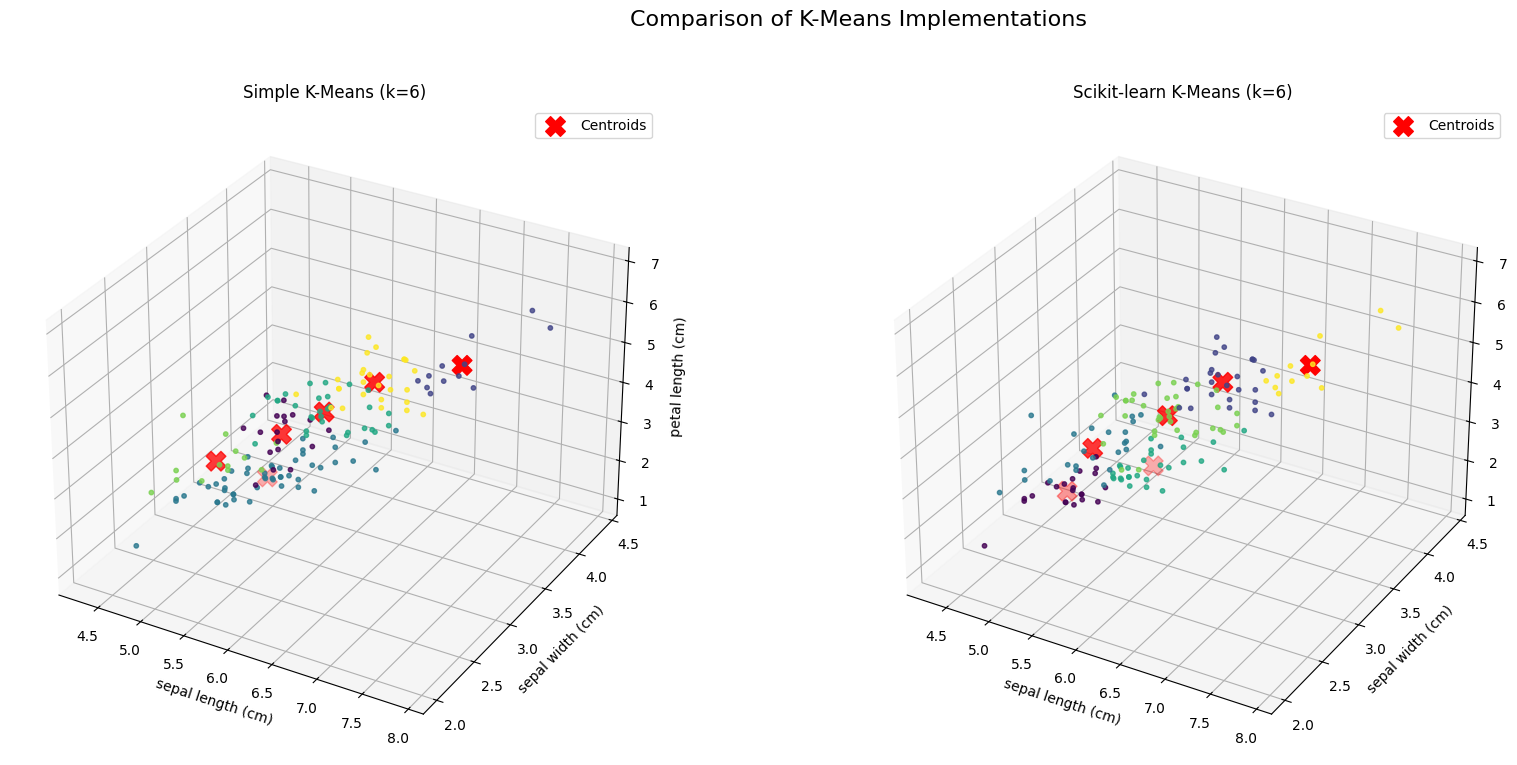

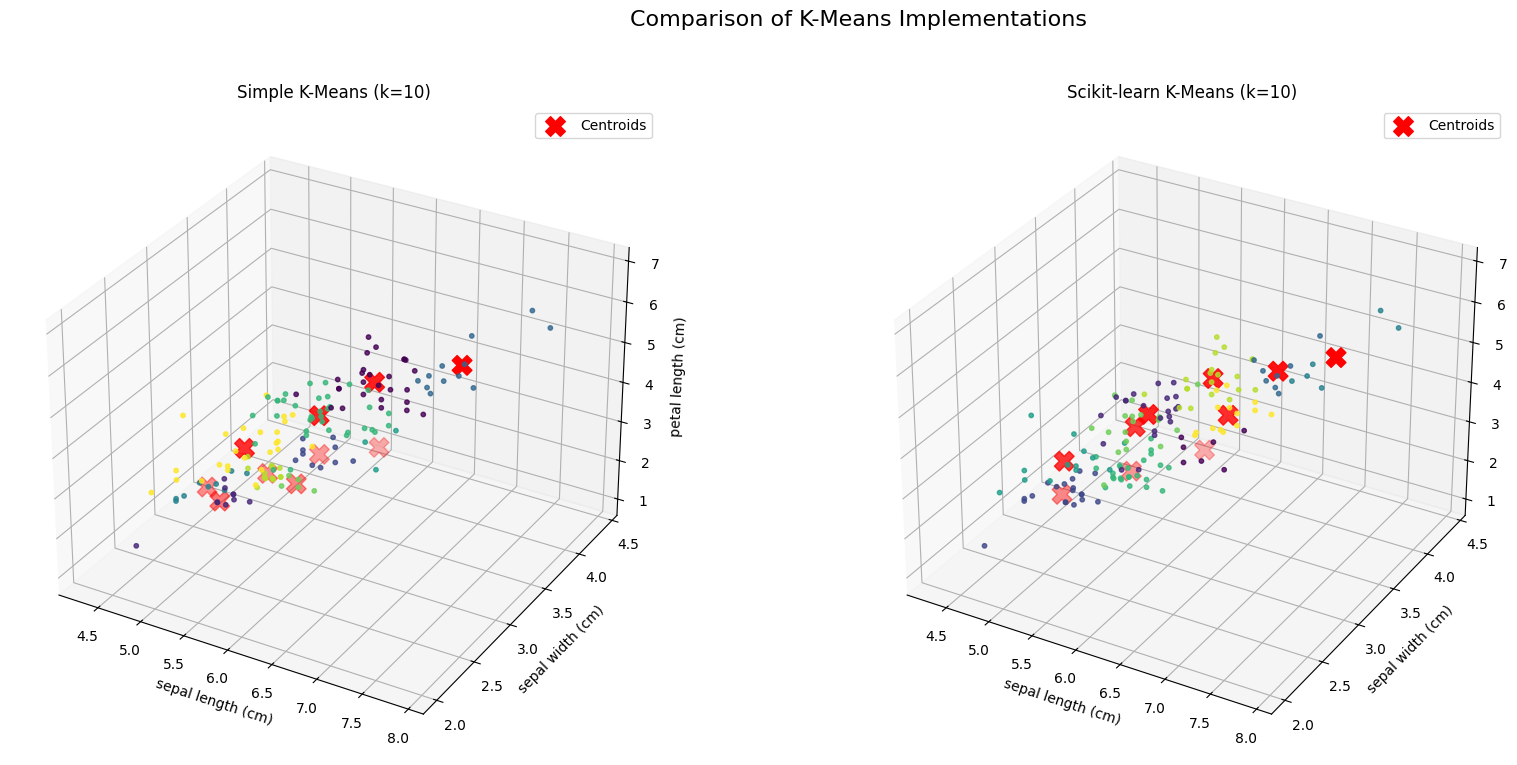

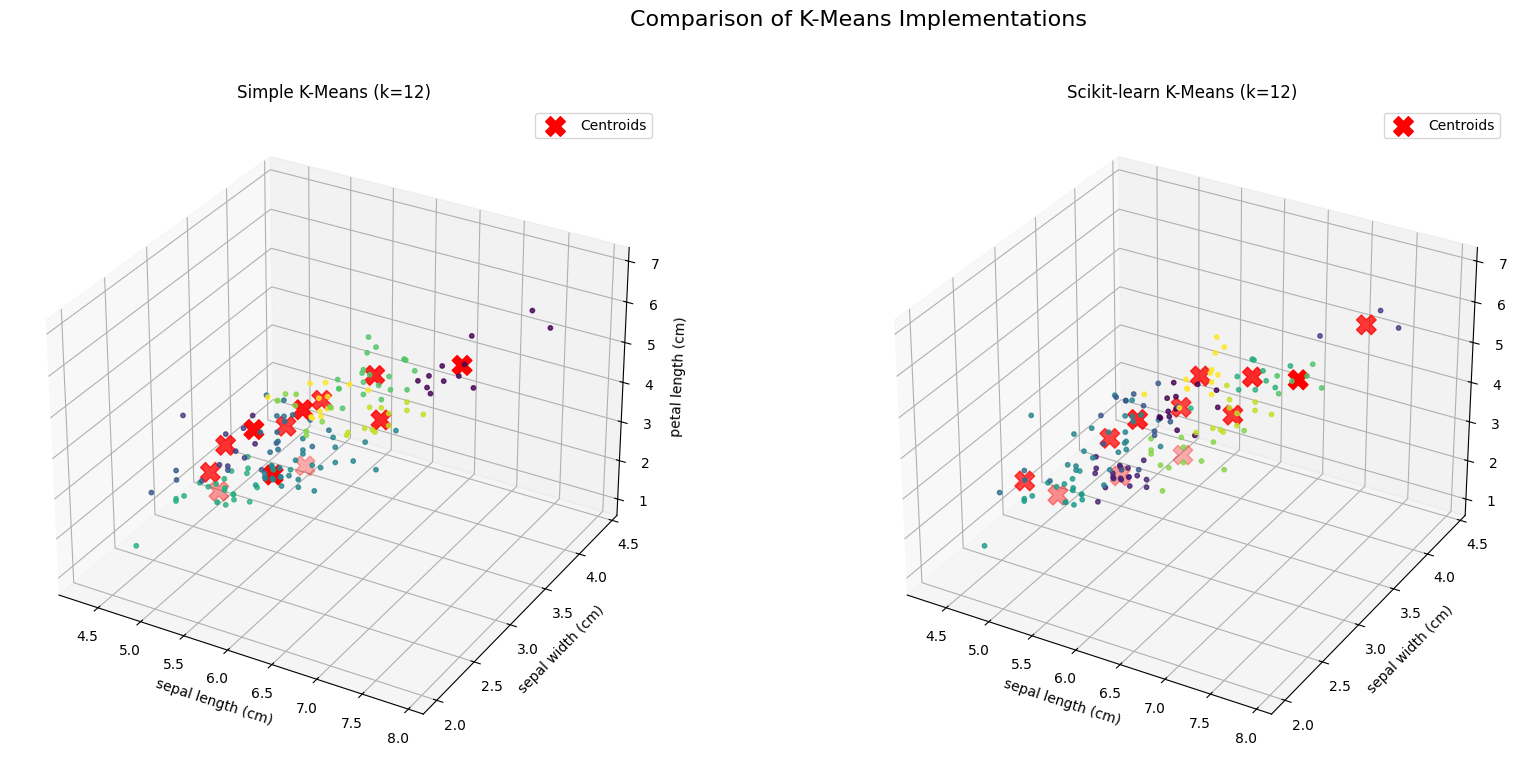

In [51]:
plot_clusters(X, y, 2)
plot_clusters(X, y, 3)
plot_clusters(X, y, 6)
plot_clusters(X, y, 10)
plot_clusters(X, y, 12)
